# 19.7) Exercício -> Importação das bibliotecas

In [80]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

Base dos dados extraidos do tratamento:

Exercicio_13-7-2_RegressoaLinear-selecionarMelhoria.ipynb

Exercicio_13-7_RegressoaLinear.ipynb

## 1) Regressão polinomial

Comece recuperando os dados previsores e alvo, de treino e de teste, a partir do arquivo `parkinson.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

In [81]:
DRIVE_DIRECTORY =''

In [82]:
import os
with open(os.path.join(DRIVE_DIRECTORY, "parkinson.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Instancie um transformador do tipo `PolynomialFeatures` com `degree=4`. Utilize ele para transformar os atributos previsores de treino e de teste.

In [83]:
poly = PolynomialFeatures(degree=4) # colocamos até 4 graus
X_train_poly = poly.fit_transform(X_train) # transformando os dados de forma polinomial
X_test_poly = poly.transform(X_test) # transformando os dados de forma polinomial

Confira o `shape` dos dados previsores de treino, antes e depois de aplicar o transformador polinomial.

In [84]:
X_train.shape, X_train_poly.shape

((4406, 19), (4406, 8855))

In [85]:
# de 7 colunas preditivas, temos mais de 300 para treino, dos parâmetros que auxiliam para prever.

### Instancie um regressor linear, e treine utilizando as variáveis preditoras polinomiais.

In [86]:
lrp = LinearRegression()
lrp.fit(X_train_poly, y_train) # treinamento com a base de dados transformada

LinearRegression()

In [87]:
lrp.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

Calcule o score deste regressor com os dados de treino.

In [88]:
lrp.score(X_train_poly, y_train)

0.7108905985760225

In [89]:
acuracia_treino = lrp.score(X_train_poly, y_train)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino')

Acurácia score 71.09 % -> treino


E também com os dados de teste.

In [90]:
lrp.score(X_test_poly, y_test)

-9.951524829953236

#### Score negativo => modelo está com o desempenho pior do que o modelo ingênuo, que sempre prevê a média dos dados reais, indicando um overfitting extremo - ou uma relação inválida entre as variáveis. 

Isso tudo acontece quando o modelo se ajusta demais aos dados de treino e falha completamente em generalizar para novos dados. 


Percebemos um alto score na base do treino e valores piores e negativos no teste.

In [91]:
acuracia_teste = lrp.score(X_test_poly, y_test)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste.')

Acurácia score -995.15 % -> teste.


Utilize o regressor para fazer predições baseadas nos dados de treinamento.

In [92]:
y_pred = lrp.predict(X_train_poly)

Exiba o erro absoluto médio para este split.

In [93]:
mean_absolute_error(y_train, y_pred)

4.345832716490084

In [94]:
# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 

# quanto menor melhor

### Comparar as variáveis

Exiba uma comparação da variável de treino entre os valores reais e preditos, na forma de um gráfico de linhas.

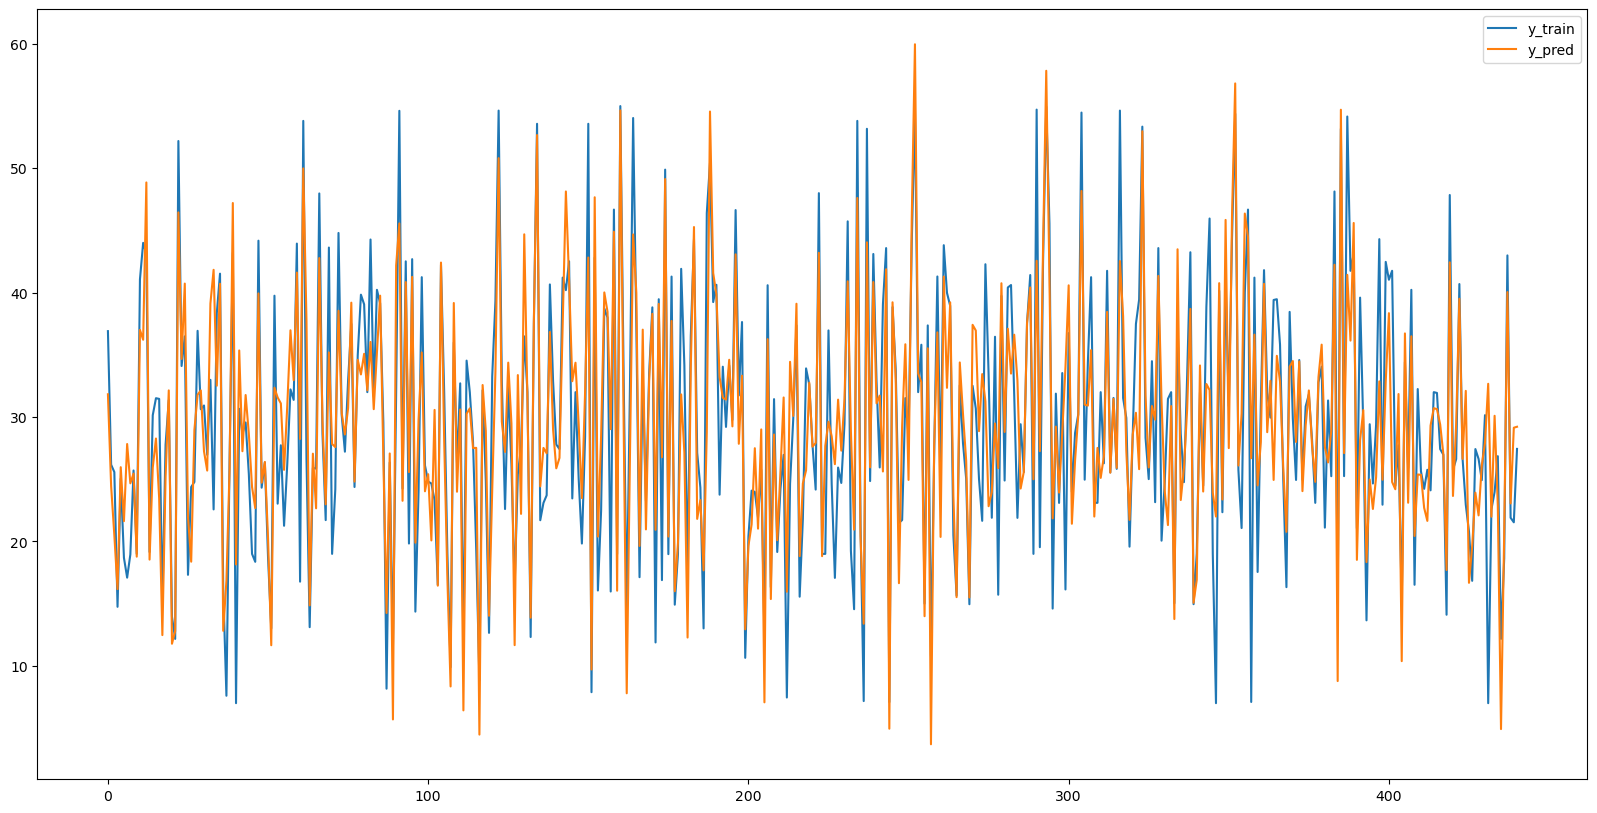

In [95]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.legend()

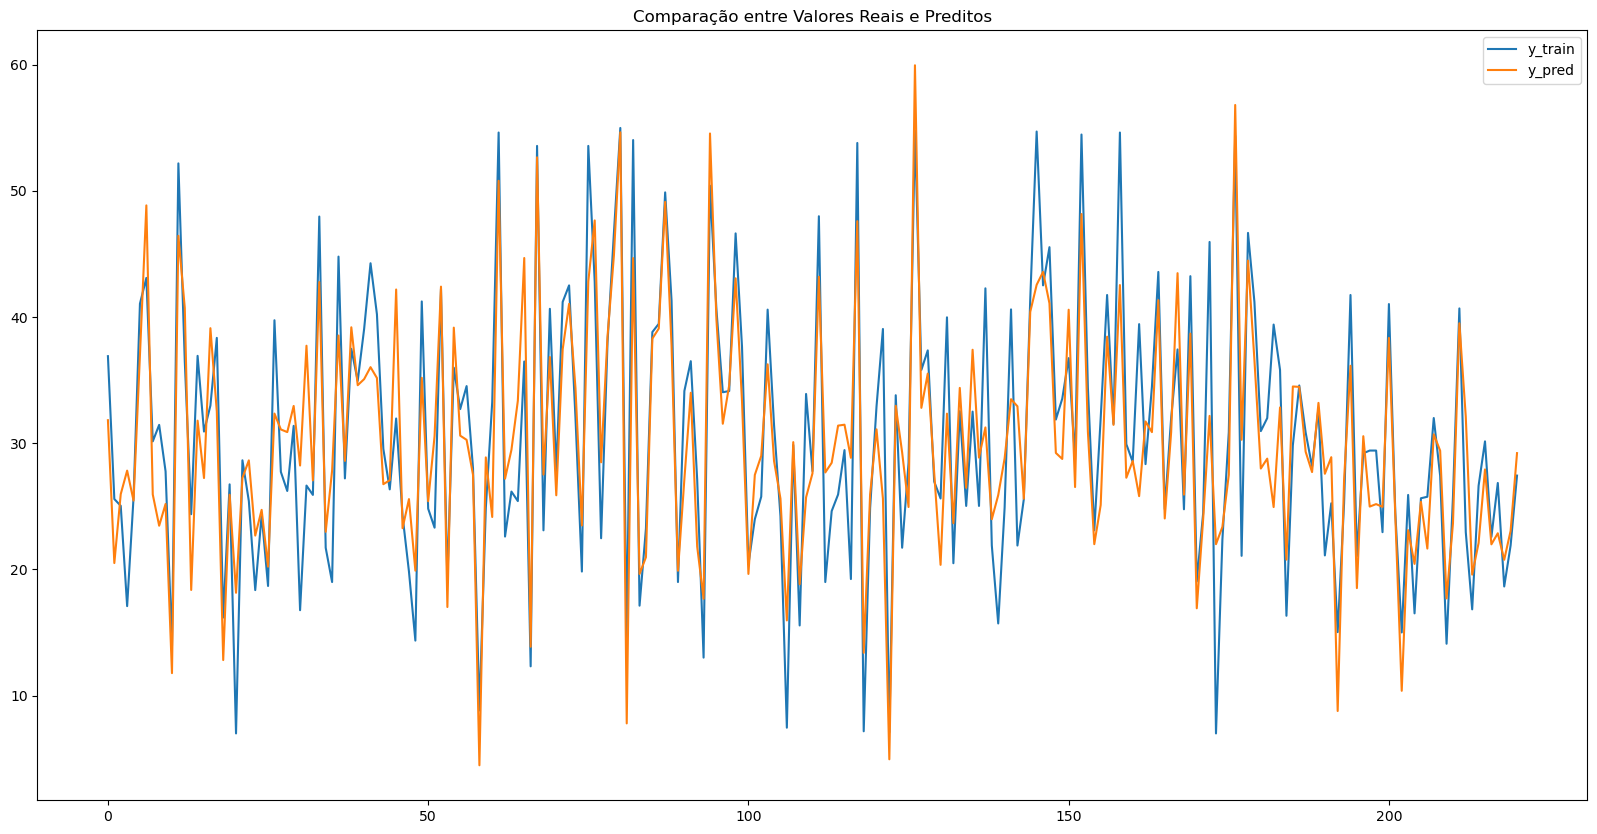

In [96]:
# modelo de treinamento se saindo bem.

plt.figure(figsize=(20, 10))
plt.plot(y_train[::20], label="y_train")
plt.plot(y_pred[::20], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos")

plt.legend()
#plt.savefig('comparacao.png')

### Tanto pelo score quanto pelo gráfico, é possível observar que, para os dados de treino, este preditor se saiu melhor do que a regressão linear múltipla da última sessão.

## Teste

Agora faça predições para os dados de teste, exiba o erro absoluto médio e o gráfico de comparação.

### Agora faça predições para os dados de teste, exiba o erro absoluto médio e o gráfico de comparação.

In [97]:
y_pred = lrp.predict(X_test_poly)

In [98]:
mean_absolute_error(y_test, y_pred)

10.09520325187047

o Erro é maior que o do treino, MAE 

In [99]:
y_pred

array([41.9209181 , 49.46835319, 26.09985043, ..., 41.21967682,
       28.62121461, 20.56139884])

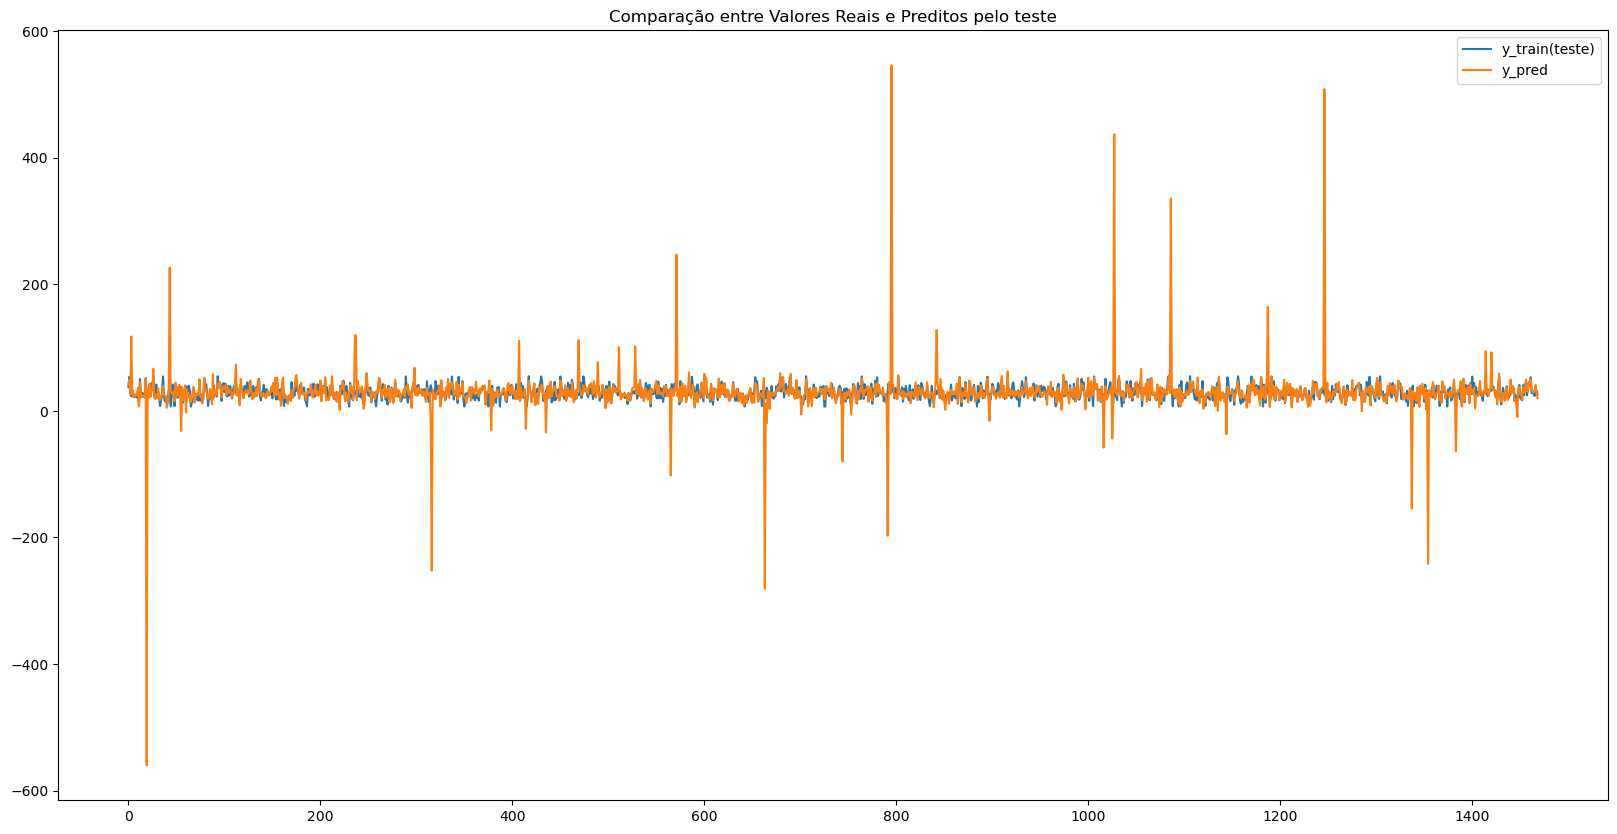

In [100]:
plt.figure(figsize=(20, 10))
plt.plot(y_test, label="y_train(teste)")
plt.plot(y_pred, label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo teste")

plt.legend()

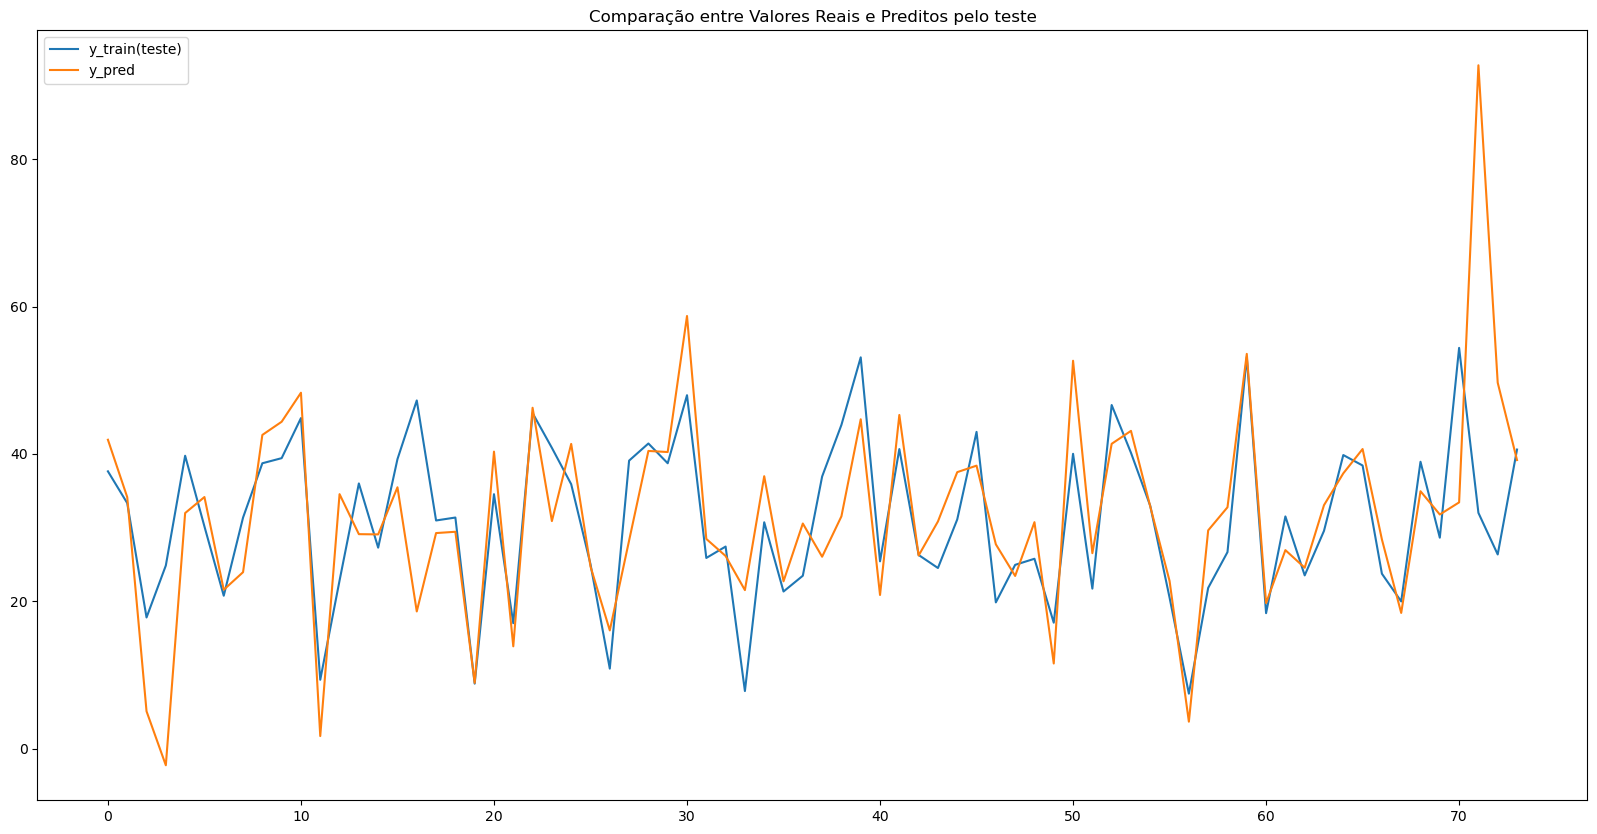

In [101]:
plt.figure(figsize=(20, 10))
plt.plot(y_test[::20], label="y_train(teste)")
plt.plot(y_pred[::20], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo teste")

plt.legend()

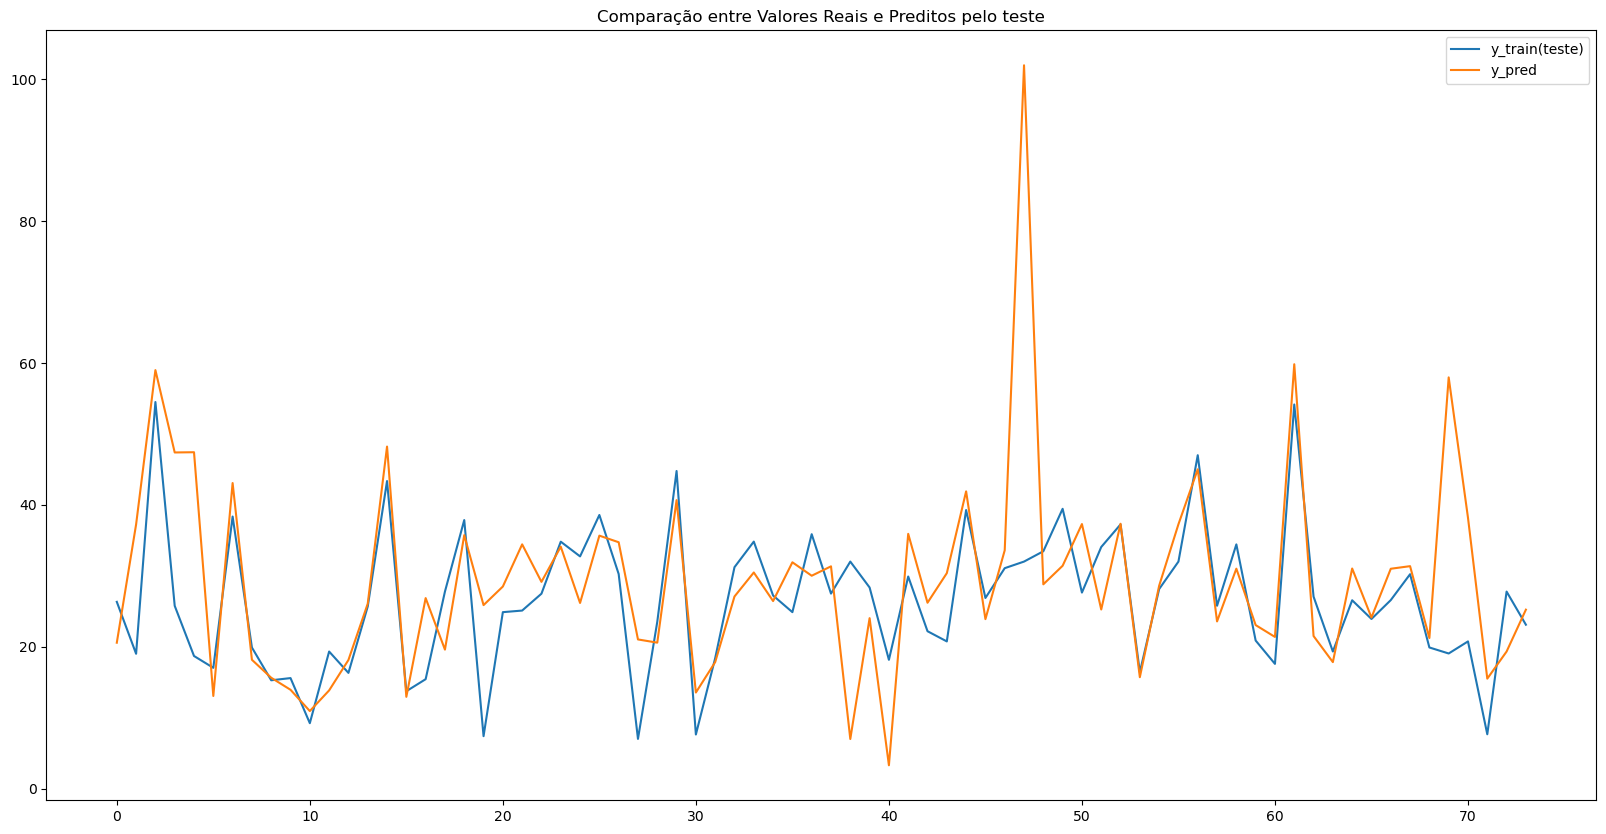

In [102]:
plt.figure(figsize=(20, 10))
plt.plot(y_test[::-20], label="y_train(teste)")
plt.plot(y_pred[::-20], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo teste")

plt.legend()

In [103]:
# os dados do teste fez previsões extremas, por isso o gráfico está achatado. 

## 2) Árvores de decisão

Instancie e treine um regressor do tipo árvore de decisão.

In [104]:
tree = DecisionTreeRegressor()  # treinar os dados do treino
tree.fit(X_train, y_train)

DecisionTreeRegressor()

In [105]:
tree.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Exiba o score deste regressor para os dados de treinamento.

In [106]:
tree.score(X_train, y_train)

1.0

In [107]:
acuracia_treino = tree.score(X_train, y_train)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino') #regressões perfeitas

Acurácia score 100.00 % -> treino


##### Este valor indica que as regressões ficaram perfeitas, coincidindo com os valores reais. Faça as predições para este split, exiba o erro absoluto médio e também a comparação no gráfico.

In [108]:
y_pred = tree.predict(X_train) # previsores

In [109]:
mean_absolute_error(y_train, y_pred) # valor do erro bom, praticamente zero

2.5641465044452096e-16

In [110]:
# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 

# quanto menor melhor

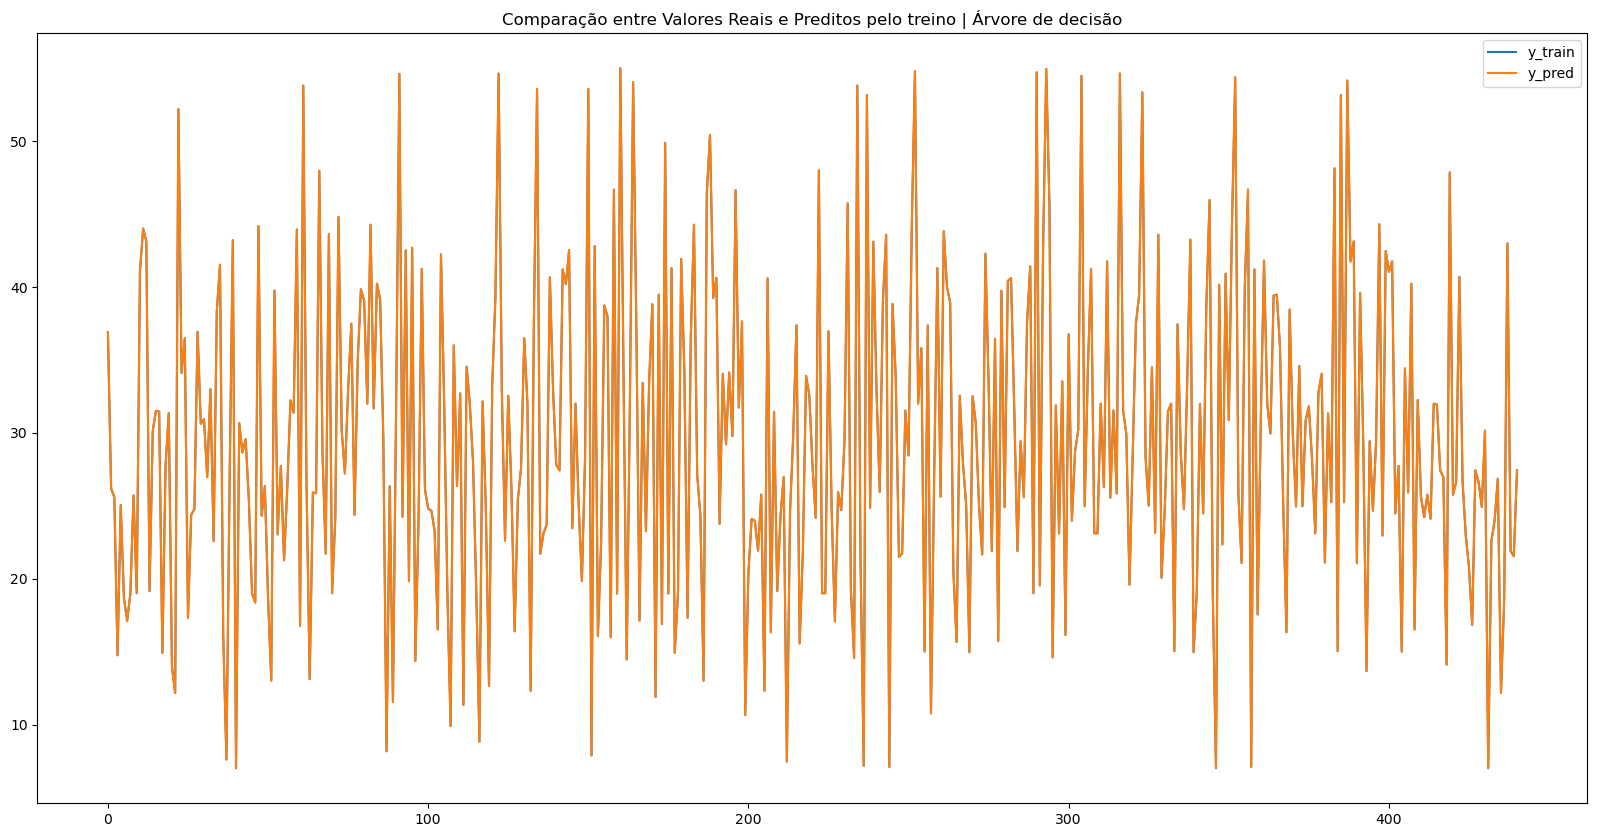

In [111]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo treino | Árvore de decisão")
plt.legend()

## O erro é aproximadamente igual a zero, e o gráfico confirma predições alinhadas com os valores reais.

### Score na base de dados do teste

Agora repita o procedimento de avaliação para o split de teste.

In [112]:
tree.score(X_test, y_test)

0.9228700396849878

In [113]:
acuracia_teste = tree.score(X_test, y_test)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste') # valor bom

Acurácia score 92.29 % -> teste


In [114]:
y_pred = tree.predict(X_test) # previsão do teste

In [115]:
mean_absolute_error(y_test, y_pred)

0.7195000000000001

In [116]:
# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 

# quanto menor melhor 

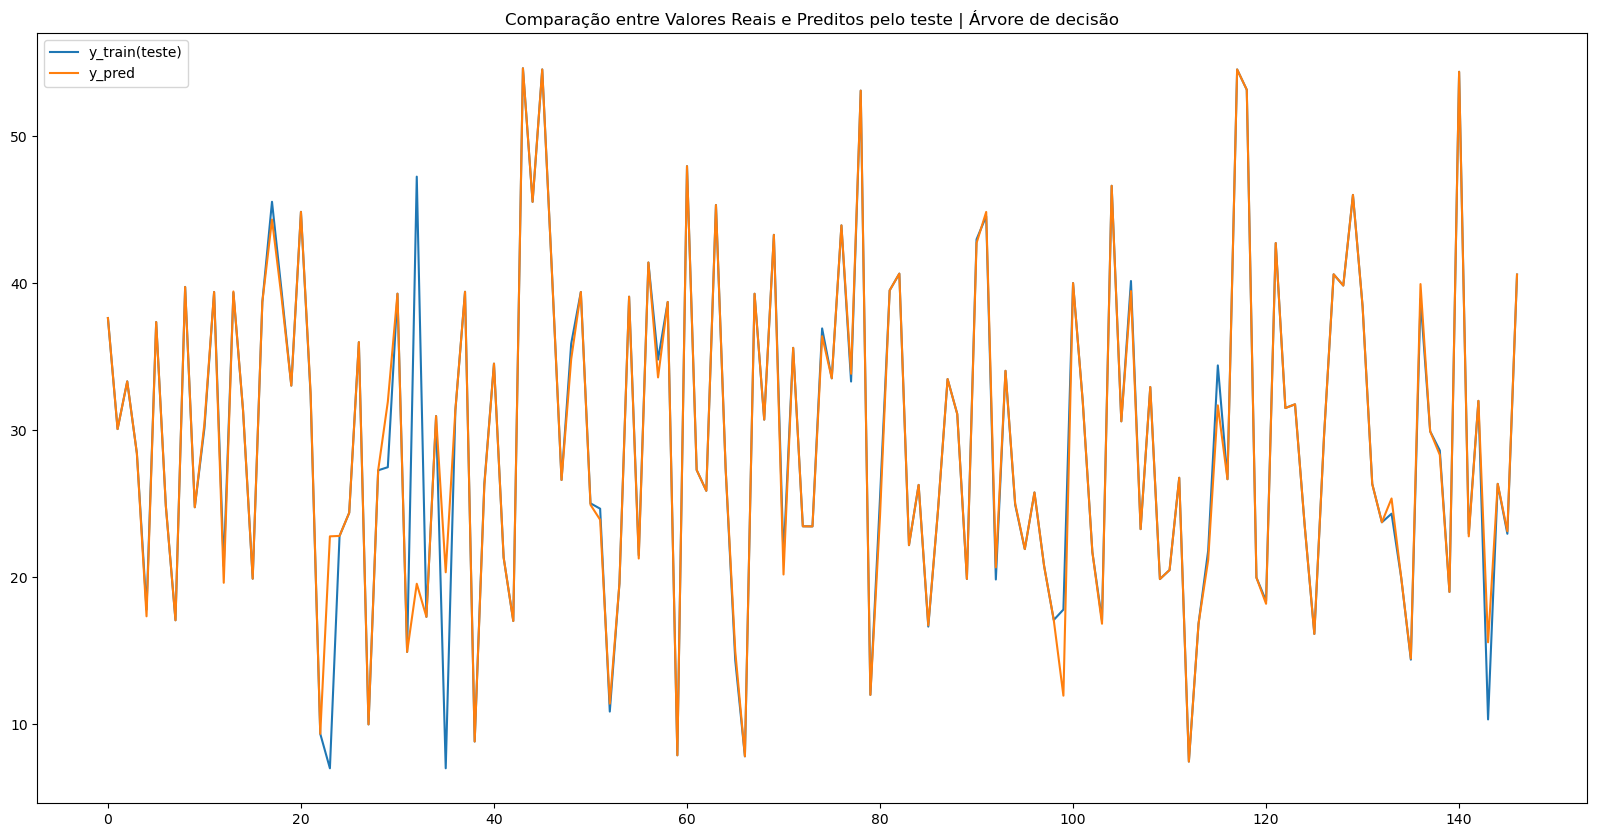

In [117]:
plt.figure(figsize=(20, 10))
plt.plot(y_test[::10], label="y_train(teste)")
plt.plot(y_pred[::10], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo teste | Árvore de decisão")
plt.legend()

### Como é normal, o desempenho no split de teste não ficou tão bom quanto no split de treinamento, mas ainda assim ficou excelente, com poucos valores preditos diferentes dos reais.

## 3) RandomForest

## exercício agora utilizando um regressor do tipo Random Forest. Utilize `n_estimators=10`.

In [118]:
rf = RandomForestRegressor(n_estimators=10)
rf.fit(X_train, y_train) # treinamento

RandomForestRegressor(n_estimators=10)

In [119]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 10,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [120]:
rf.score(X_train, y_train)

0.9914681792767259

In [121]:
acuracia_treino = rf.score(X_train, y_train)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino') # valor bom

Acurácia score 99.15 % -> treino


In [122]:
y_pred = rf.predict(X_train)

In [123]:
mean_absolute_error(y_train, y_pred)

0.4097441488878806

In [124]:
# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 
# quanto menor melhor

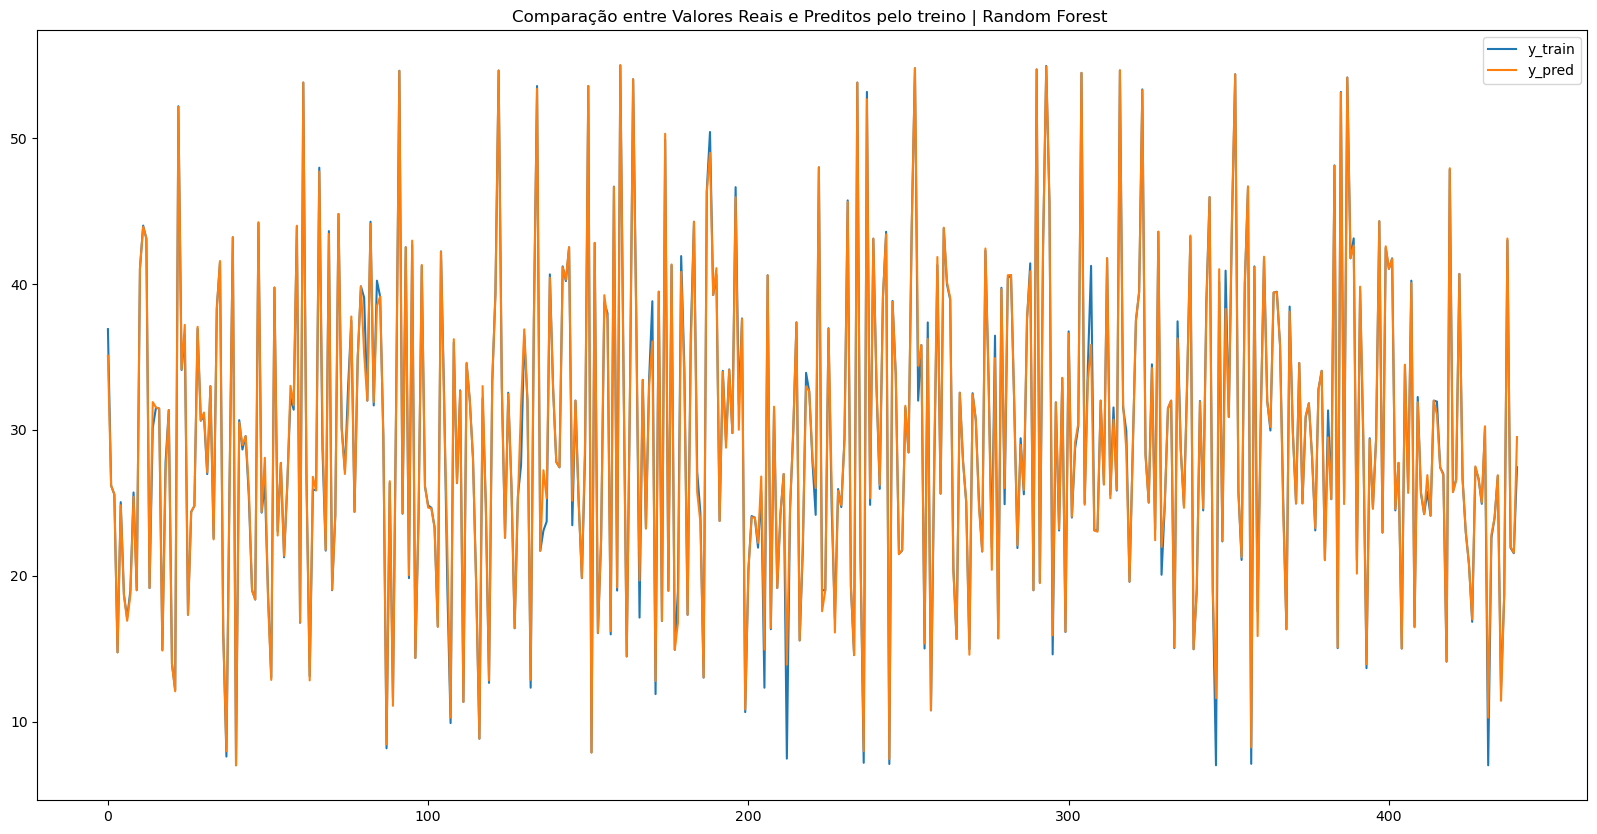

In [125]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo treino | Random Forest ")
plt.legend()

Este regressor ficou um pouco pior que a árvore de decisão no split de treinamento, mas ainda assim muito bom!

### E no split de teste?

In [126]:
rf.score(X_test, y_test) # valor muito bom 

0.9542770294744307

In [127]:
acuracia_teste = rf.score(X_test, y_test)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste') # valor bom superou as acurácias anteriores

Acurácia score 95.43 % -> teste


In [128]:
y_pred = rf.predict(X_test) # previsões do teste

In [129]:
mean_absolute_error(y_test, y_pred) # calcular o valor do erro. 

# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 
# quanto menor melhor

1.0384712933968685

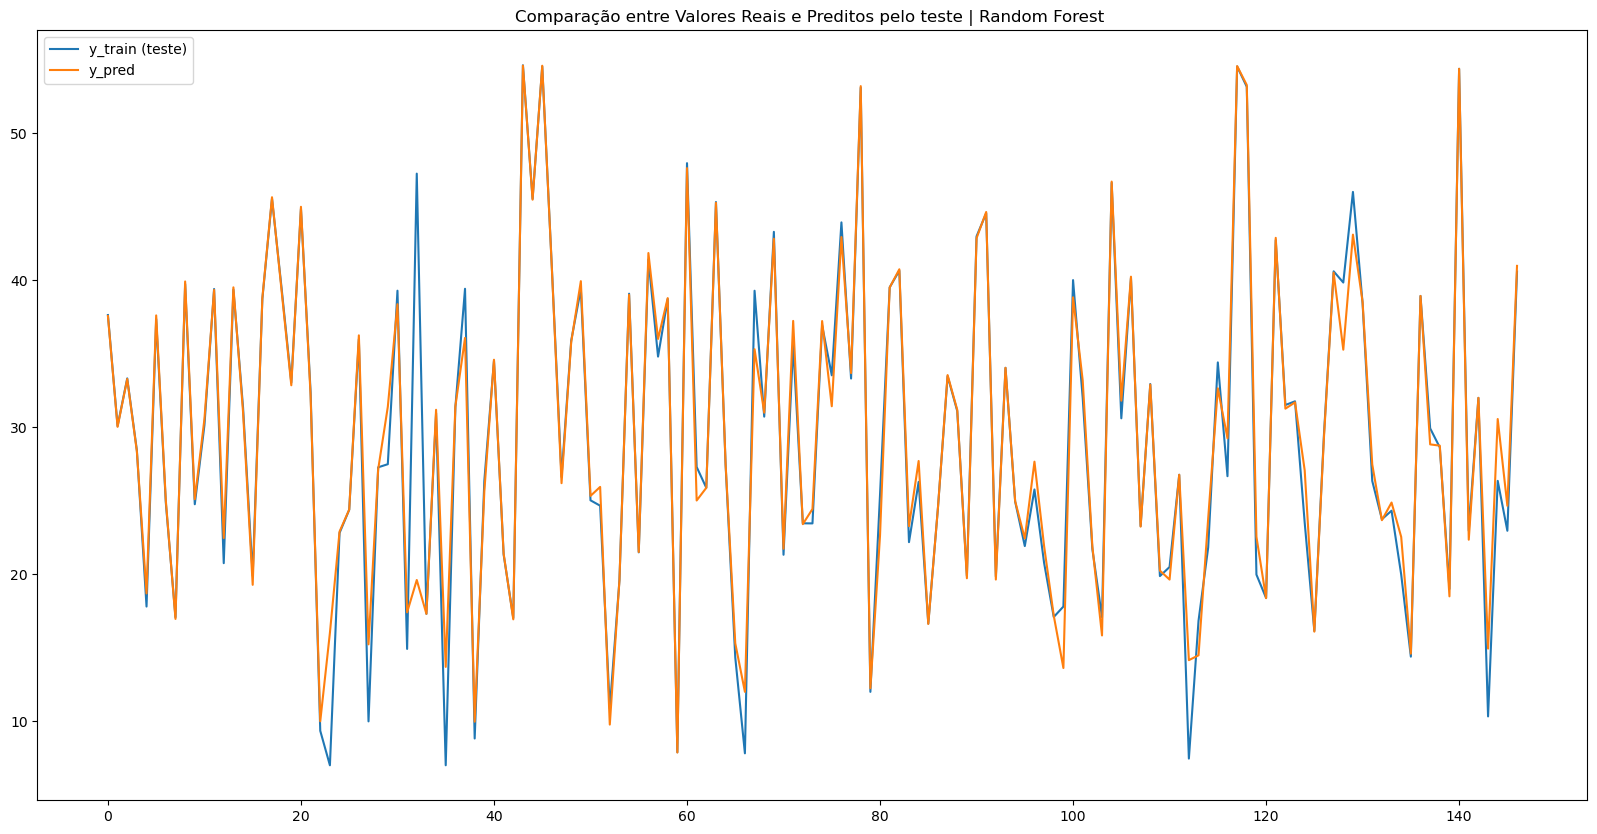

In [130]:
plt.figure(figsize=(20, 10))
plt.plot(y_test[::10], label="y_train (teste)")
plt.plot(y_pred[::10], label="y_pred")
plt.title("Comparação entre Valores Reais e Preditos pelo teste | Random Forest ")
plt.legend()

### O score ficou um pouco melhor que a árvore de decisão, apesar de o erro médio ter ficado um pouco maior. Isso indica que, em média, o erro aumentou, mas temos menos valores extremos.

## 4) SVM

### 4.1) Instancie um regressor do tipo SVM, com `kernel="linear"`, e ajuste com os dados de treino.

In [131]:
svr = SVR(kernel="linear")
svr.fit(X_train, y_train)  # treinar o modelo

SVR(kernel='linear')

In [132]:
svr.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [133]:
svr.score(X_train, y_train)

0.14348639244187023

In [136]:
acuracia_treino = svr.score(X_train, y_train)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino') 

Acurácia score 14.35 % -> treino


In [134]:
svr.score(X_test, y_test)

0.12220028694598939

In [135]:
acuracia_teste = svr.score(X_test, y_test)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste') 

Acurácia score 12.22 % -> teste


Valores ruins do score.

Este regressor não se saiu muito bem.

#### 4.2) Instancie e treine outro regressor do tipo SVM, mas agora com `kernel="poly"` e `degree=4`.

Kernel polinomial

In [137]:
svr_poly = SVR(kernel="poly", degree=4)
svr_poly.fit(X_train, y_train) # treinamento

SVR(degree=4, kernel='poly')

In [138]:
svr_poly.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 4,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'poly',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

Exiba os scores.

In [139]:
svr_poly.score(X_train, y_train)

0.04909745897454887

In [140]:
svr_poly.score(X_test, y_test)

0.045542317536285126

In [141]:

acuracia_treino = svr_poly.score(X_train, y_train)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino') 

acuracia_teste = svr_poly.score(X_test, y_test)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste') 

Acurácia score 4.91 % -> treino
Acurácia score 4.55 % -> teste


O resultado ficou ainda pior.

### 4.3) Agora vamos tentar um regressor SVM com `kernel="rbf"`. Para isso, primeiro precisamos escalonar os valores.

Instancie um escalonador para os atributos previsores, e outro para o atributo alvo, ambos do tipo `StandardScaler`.

Padronizar  => tipo `StandardScaler`.

In [142]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

Agora escalone os dados de treinamento. Lembre-se que, no caso de `y`, você deve primeiro utilizar `reshape(-1, 1)`, para apresentá-los ao escalonador no formato coluna, e depois da transformação, voltar a linearizá-lo com `ravel()`.

In [143]:
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

In [144]:
X_train,X_train_scaled

(array([[5.7000e+01, 1.2626e+02, 2.5800e-03, ..., 5.8921e-01, 9.7793e-02,
         0.0000e+00],
        [5.9000e+01, 1.2847e+02, 2.8500e-03, ..., 6.1591e-01, 1.2635e-01,
         1.0000e+00],
        [6.2000e+01, 1.6820e+02, 2.9500e-03, ..., 6.1425e-01, 1.7362e-01,
         0.0000e+00],
        ...,
        [6.2000e+01, 1.7519e+02, 1.3280e-02, ..., 6.9895e-01, 3.2500e-01,
         0.0000e+00],
        [5.5000e+01, 1.9579e+02, 1.4930e-02, ..., 7.3339e-01, 3.4876e-01,
         0.0000e+00],
        [6.7000e+01, 1.4492e+02, 5.6100e-03, ..., 7.7725e-01, 2.3529e-01,
         0.0000e+00]]),
 array([[-0.91088495,  0.63150632, -0.64788044, ..., -0.89604571,
         -1.33378991, -0.68673859],
        [-0.68147805,  0.67284885, -0.59816539, ..., -0.52096084,
         -1.02138272,  1.45615816],
        [-0.33736769,  1.41607917, -0.5797524 , ..., -0.54428073,
         -0.50425951, -0.68673859],
        ...,
        [-0.33736769,  1.54684131,  1.32230885, ...,  0.64559524,
          1.15180379, -0

In [145]:
y_train,y_train_scaled

(array([36.903, 27.275, 22.946, ..., 23.122, 26.002, 16.559]),
 array([ 0.72879926, -0.16587429, -0.56814286, ..., -0.55178821,
        -0.28416671, -1.1616493 ]))

In [146]:
y_train.reshape(-1, 1).ravel()

array([36.903, 27.275, 22.946, ..., 23.122, 26.002, 16.559])

Transforme também os dados de teste.

In [147]:
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [149]:
X_test, '', X_test_scaled

(array([[6.8000e+01, 7.4840e+00, 7.9600e-03, ..., 7.0003e-01, 2.5145e-01,
         1.0000e+00],
        [7.1000e+01, 1.3422e+01, 1.6860e-02, ..., 7.4990e-01, 4.1199e-01,
         0.0000e+00],
        [5.9000e+01, 1.6341e+02, 4.0300e-03, ..., 6.9314e-01, 1.7536e-01,
         1.0000e+00],
        ...,
        [6.8000e+01, 1.4492e+01, 5.9400e-03, ..., 7.0631e-01, 2.7500e-01,
         1.0000e+00],
        [4.9000e+01, 2.4844e+01, 8.2900e-03, ..., 7.1589e-01, 2.7668e-01,
         0.0000e+00],
        [8.5000e+01, 1.4701e+01, 3.6800e-03, ..., 5.7989e-01, 1.7567e-01,
         1.0000e+00]]),
 '',
 array([[ 0.35085303, -1.59043992,  0.3427381 , ...,  0.66076721,
          0.34718326,  1.45615816],
        [ 0.69496338, -1.47935757,  1.98149368, ...,  1.36134707,
          2.10345491, -0.68673859],
        [-0.68147805,  1.32647249, -0.38089217, ...,  0.56397565,
         -0.4852243 ,  1.45615816],
        ...,
        [ 0.35085303, -1.45934105, -0.02920418, ...,  0.74898942,
          0.6048149

In [150]:
y_test, '',y_test_scaled

(array([37.635, 54.153, 26.443, ..., 38.23 , 31.38 , 26.323]),
 '',
 array([ 0.79681973,  2.33174056, -0.24318717, ...,  0.85210959,
         0.21557928, -0.25433806]))

Agora sim instancie o regressor e ajuste com os dados escalonados.

In [151]:
# treinar 

svr_rbf = SVR(kernel="rbf")
svr_rbf.fit(X_train_scaled, y_train_scaled)


SVR()

In [152]:
svr_rbf.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

Exiba os scores do regressor.

In [153]:
svr_rbf.score(X_train_scaled, y_train_scaled)

0.5004794038369796

In [154]:
svr_rbf.score(X_test_scaled, y_test_scaled)

0.46303967528856593

In [155]:

acuracia_treino = svr_rbf.score(X_train_scaled, y_train_scaled)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino') 

acuracia_teste = svr_rbf.score(X_test_scaled, y_test_scaled)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste') 

Acurácia score 50.05 % -> treino
Acurácia score 46.30 % -> teste


Os resultados melhoraram em comparação aos outros kernels. Porém, não tão bom quanto a árvore de decisão.

Utilize o regressor para fazer predições no split de teste. Depois, como esses dados estão escalonados, utilize o método `inverse_transform` do escalonador para retorná-los à escala original. Lembre-se dos cuidados com os `shape`s ao invocar o escalonador.

In [157]:
y_pred = svr_rbf.predict(X_test_scaled)  # preditor na base de teste
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel() # retornar a forma original o dado previsão.

Agora exiba o erro absoluto médio para os dados de teste em sua escala original.

In [158]:
mean_absolute_error(y_test, y_pred)

# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 
# quanto menor melhor

5.616380997616378

## 5) Redes neurais artificiais

Instancie um regressor do tipo rede neural, com `max_iter=1000`. Treine este modelo com os dados escalonados.

In [160]:
neural_net = MLPRegressor(max_iter=1000)
neural_net.fit(X_train_scaled, y_train_scaled) # treinar

MLPRegressor(max_iter=1000)

In [161]:
neural_net.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 1000,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

Exiba os scores do regressor.

In [162]:
neural_net.score(X_train_scaled, y_train_scaled)

0.757454698622996

In [163]:
neural_net.score(X_test_scaled, y_test_scaled)

0.6683221334403051

In [164]:

acuracia_treino = neural_net.score(X_train_scaled, y_train_scaled)
print(f'Acurácia score {acuracia_treino*100:.2f} % -> treino') 

acuracia_teste = neural_net.score(X_test_scaled, y_test_scaled)
print(f'Acurácia score {acuracia_teste*100:.2f} % -> teste') 

Acurácia score 75.75 % -> treino
Acurácia score 66.83 % -> teste


Faça predições para os dados de teste. Lembre-se de, depois, retornar os valores preditos para sua escala original.

In [166]:
y_pred = neural_net.predict(X_test_scaled)
print(y_pred)

y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
print(y_pred)

[ 1.40083589  1.38444659 -0.22558874 ...  1.35159327 -0.14359266
 -0.23384257]
[44.13510002 43.95872709 26.63238492 ... 43.60517722 27.51478306
 26.54356162]


Exiba o erro absoluto médio para os dados de teste.

In [168]:
mean_absolute_error(y_test, y_pred)
# MAE, significa que pode erra tanto para mais ou tanto para menos com o valor o MAE. 
# quanto menor melhor

4.4787808264502145

In [169]:
# os melhores resultados foram com o random forest e pela árvore de decisão.